In [1]:
import copy
import random

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
from gymnasium.spaces import Box
from tqdm import tqdm

## SAC - Soft Actor-Critic (Haarnoja et al., 2018)

This notebook follows the modern SAC variant described in the Spinning Up notes: an off-policy stochastic actor-critic for continuous control.

Core loop in plain words:

```text
initialize actor pi_theta, two critics Q_phi1 and Q_phi2, target critics Q_targ1 and Q_targ2
for each environment step:
    act randomly for start_steps, then sample a ~ pi_theta(. | s)
    store (s, a, r, s_next, done) in replay buffer
    every update_every steps after update_after:
        sample minibatches from replay buffer
        update both Q networks toward the soft Bellman target
        update the actor with the reparameterized entropy-regularized objective
        Polyak-average target Q parameters
```

**Soft Q target used here:**

```text
y = r + gamma * (1 - done) * (min(Q_targ1(s_next, a_next), Q_targ2(s_next, a_next)) - alpha * log pi(a_next | s_next))
```

**Actor loss minimized here:**

```text
L_pi = mean(alpha * log pi(a_pi | s) - min(Q_phi1(s, a_pi), Q_phi2(s, a_pi)))
```

`alpha` is fixed in this notebook, matching the simple Spinning Up implementation. The later automatic-temperature variant is useful for serious tuning, but the fixed coefficient makes the mechanics easier to inspect.

### 1. ReplayBuffer

SAC is off-policy like DQN, so transitions are reused from a replay buffer. Unlike DQN, actions are continuous vectors, so the buffer stores `actions` as float arrays instead of action indices.

The `done` flag intentionally records only true termination. Gymnasium time-limit truncation resets the environment, but it is not a terminal state for the infinite-horizon Bellman target.

In [2]:
class ReplayBuffer(object):
    def __init__(self, obs_dim, act_dim, size, batch_size, device):
        self.obs_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.obs2_buf = np.zeros((size, obs_dim), dtype=np.float32)
        self.act_buf = np.zeros((size, act_dim), dtype=np.float32)
        self.rew_buf = np.zeros(size, dtype=np.float32)
        self.done_buf = np.zeros(size, dtype=np.float32)
        self.max_size = size
        self.batch_size = batch_size
        self.device = device
        self.ptr = 0
        self.size = 0

    def insert(self, obs, act, rew, next_obs, done):
        self.obs_buf[self.ptr] = obs
        self.obs2_buf[self.ptr] = next_obs
        self.act_buf[self.ptr] = act
        self.rew_buf[self.ptr] = rew
        self.done_buf[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.max_size
        self.size = min(self.size + 1, self.max_size)

    def sample(self):
        if self.size < self.batch_size:
            raise ValueError("Not enough samples in replay buffer")

        idxs = np.random.randint(0, self.size, size=self.batch_size)
        batch = dict(
            obs=self.obs_buf[idxs],
            obs2=self.obs2_buf[idxs],
            act=self.act_buf[idxs],
            rew=self.rew_buf[idxs],
            done=self.done_buf[idxs],
        )
        return {
            key: torch.as_tensor(value, dtype=torch.float32, device=self.device)
            for key, value in batch.items()
        }

    def __len__(self):
        return self.size

### 2. Actor and Critic Networks

The actor is a state-dependent Gaussian policy followed by `tanh`, then scaled to the environment action bounds. This is the usual SAC policy family because it can sample differentiably with `rsample()` and still respect finite action limits.

Each critic maps `(state, action)` to one scalar Q-value. SAC keeps two critics and uses the smaller estimate in both the target and policy objective, which reduces overestimation bias.

In [3]:
LOG_STD_MIN = -20
LOG_STD_MAX = 2


def mlp(sizes, activation=nn.ReLU, output_activation=nn.Identity):
    layers = []
    for j in range(len(sizes) - 1):
        act = activation if j < len(sizes) - 2 else output_activation
        layers += [nn.Linear(sizes[j], sizes[j + 1]), act()]
    return nn.Sequential(*layers)


class SquashedGaussianActor(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes, action_low, action_high):
        super().__init__()
        self.net = mlp([obs_dim, *hidden_sizes], nn.ReLU, nn.ReLU)
        self.mu_layer = nn.Linear(hidden_sizes[-1], act_dim)
        self.log_std_layer = nn.Linear(hidden_sizes[-1], act_dim)

        action_low = torch.as_tensor(action_low, dtype=torch.float32)
        action_high = torch.as_tensor(action_high, dtype=torch.float32)
        self.register_buffer("action_scale", (action_high - action_low) / 2.0)
        self.register_buffer("action_bias", (action_high + action_low) / 2.0)

    def forward(self, obs, deterministic=False, with_logprob=True):
        net_out = self.net(obs)
        mu = self.mu_layer(net_out)
        log_std = torch.clamp(self.log_std_layer(net_out), LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std)
        dist = Normal(mu, std)

        pre_tanh = mu if deterministic else dist.rsample()
        action = torch.tanh(pre_tanh)
        scaled_action = self.action_bias + self.action_scale * action

        logp = None
        if with_logprob:
            logp = dist.log_prob(pre_tanh).sum(dim=-1)
            squash_correction = 2 * (np.log(2) - pre_tanh - F.softplus(-2 * pre_tanh))
            logp = logp - squash_correction.sum(dim=-1)
            logp = logp - torch.log(self.action_scale).sum()

        return scaled_action, logp


class QNetwork(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes):
        super().__init__()
        self.q = mlp([obs_dim + act_dim, *hidden_sizes, 1])

    def forward(self, obs, act):
        q = self.q(torch.cat([obs, act], dim=-1))
        return torch.squeeze(q, -1)


class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes, action_low, action_high):
        super().__init__()
        self.pi = SquashedGaussianActor(obs_dim, act_dim, hidden_sizes, action_low, action_high)
        self.q1 = QNetwork(obs_dim, act_dim, hidden_sizes)
        self.q2 = QNetwork(obs_dim, act_dim, hidden_sizes)

    def act(self, obs, deterministic=False):
        if not torch.is_tensor(obs):
            obs = torch.as_tensor(obs, dtype=torch.float32, device=next(self.parameters()).device)
        if obs.ndim == 1:
            obs = obs.unsqueeze(0)

        with torch.no_grad():
            action, _ = self.pi(obs, deterministic=deterministic, with_logprob=False)
        return action.cpu().numpy()[0]

### 3. RunSAC - Spinning Up Style Training Loop

Methods map directly to the SAC pseudocode:

| Method | Role |
|---|---|
| `choose_action` | uniform random warmup, then stochastic policy action |
| `_compute_loss_q` | Bellman backup with clipped double-Q and entropy term |
| `_compute_loss_pi` | reparameterized actor objective |
| `_update` | critic step, actor step, then Polyak target update |
| `learn` | step-based environment interaction loop |

`update_every` follows Spinning Up: every `k` environment steps, the code performs `k` gradient updates, keeping the long-run environment-step to gradient-step ratio near 1.

In [4]:
class RunSAC(object):
    def __init__(self,
                 env,
                 lr=1e-3,
                 batch_size=100,
                 gamma=0.99,
                 polyak=0.995,
                 alpha=0.2,
                 hidden_sizes=(256, 256),
                 replay_size=1_000_000,
                 start_steps=10_000,
                 update_after=1_000,
                 update_every=50,
                 max_ep_len=1_000,
                 grad_clip=None,
                 device=None):

        if not isinstance(env.action_space, Box):
            raise ValueError("SAC in this notebook expects a continuous Box action space")
        if not np.all(np.isfinite(env.action_space.low)) or not np.all(np.isfinite(env.action_space.high)):
            raise ValueError("SAC needs finite action bounds for tanh-squashed actions")

        self.env = env
        self.lr = lr
        self.batch_size = batch_size
        self.gamma = gamma
        self.polyak = polyak
        self.alpha = alpha
        self.hidden_sizes = tuple(hidden_sizes)
        self.replay_size = replay_size
        self.start_steps = start_steps
        self.update_after = update_after
        self.update_every = update_every
        self.max_ep_len = max_ep_len
        self.grad_clip = grad_clip
        self.device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))

        self.dim_S = env.observation_space.shape[0]
        self.dim_A = env.action_space.shape[0]

        self.replay_buffer = ReplayBuffer(
            obs_dim=self.dim_S,
            act_dim=self.dim_A,
            size=self.replay_size,
            batch_size=self.batch_size,
            device=self.device,
        )

        self.ac = ActorCritic(
            obs_dim=self.dim_S,
            act_dim=self.dim_A,
            hidden_sizes=self.hidden_sizes,
            action_low=env.action_space.low,
            action_high=env.action_space.high,
        ).to(self.device)
        self.ac_targ = copy.deepcopy(self.ac).to(self.device)

        for param in self.ac_targ.parameters():
            param.requires_grad = False

        self.q_params = list(self.ac.q1.parameters()) + list(self.ac.q2.parameters())
        self.pi_optimizer = optim.Adam(self.ac.pi.parameters(), lr=self.lr)
        self.q_optimizer = optim.Adam(self.q_params, lr=self.lr)

        self.total_env_steps = 0
        self.total_updates = 0

    def _reset_env(self, seed=None):
        reset_result = self.env.reset(seed=seed) if seed is not None else self.env.reset()
        return reset_result[0] if isinstance(reset_result, tuple) else reset_result

    def _step_env(self, action):
        step_result = self.env.step(action)
        if len(step_result) == 5:
            next_state, reward, terminated, truncated, _ = step_result
        else:
            next_state, reward, done, _ = step_result
            terminated, truncated = done, False
        return next_state, reward, terminated, truncated

    def choose_action(self, state, deterministic=False):
        if deterministic:
            return self.ac.act(state, deterministic=True)
        if self.total_env_steps < self.start_steps:
            return self.env.action_space.sample()
        return self.ac.act(state, deterministic=False)

    def _compute_loss_q(self, batch):
        obs, act = batch["obs"], batch["act"]
        rew, obs2, done = batch["rew"], batch["obs2"], batch["done"]

        q1 = self.ac.q1(obs, act)
        q2 = self.ac.q2(obs, act)

        with torch.no_grad():
            next_action, logp_next_action = self.ac.pi(obs2)
            q1_targ = self.ac_targ.q1(obs2, next_action)
            q2_targ = self.ac_targ.q2(obs2, next_action)
            q_targ = torch.min(q1_targ, q2_targ)
            backup = rew + self.gamma * (1 - done) * (q_targ - self.alpha * logp_next_action)

        loss_q1 = F.mse_loss(q1, backup)
        loss_q2 = F.mse_loss(q2, backup)
        loss_q = loss_q1 + loss_q2

        return loss_q, {
            "loss_q1": loss_q1.item(),
            "loss_q2": loss_q2.item(),
            "q1": q1.mean().item(),
            "q2": q2.mean().item(),
        }

    def _compute_loss_pi(self, batch):
        obs = batch["obs"]
        action, logp_action = self.ac.pi(obs)
        q1_pi = self.ac.q1(obs, action)
        q2_pi = self.ac.q2(obs, action)
        q_pi = torch.min(q1_pi, q2_pi)
        loss_pi = (self.alpha * logp_action - q_pi).mean()

        return loss_pi, {
            "loss_pi": loss_pi.item(),
            "logp_pi": logp_action.mean().item(),
            "q_pi": q_pi.mean().item(),
        }

    def _polyak_update(self):
        with torch.no_grad():
            for param, param_targ in zip(self.ac.parameters(), self.ac_targ.parameters()):
                param_targ.data.mul_(self.polyak)
                param_targ.data.add_((1 - self.polyak) * param.data)

    def _update(self):
        batch = self.replay_buffer.sample()

        self.q_optimizer.zero_grad()
        loss_q, q_info = self._compute_loss_q(batch)
        loss_q.backward()
        if self.grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(self.q_params, self.grad_clip)
        self.q_optimizer.step()

        for param in self.q_params:
            param.requires_grad = False

        self.pi_optimizer.zero_grad()
        loss_pi, pi_info = self._compute_loss_pi(batch)
        loss_pi.backward()
        if self.grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(self.ac.pi.parameters(), self.grad_clip)
        self.pi_optimizer.step()

        for param in self.q_params:
            param.requires_grad = True

        self._polyak_update()
        self.total_updates += 1

        return {**q_info, **pi_info}

    def test_agent(self, num_episodes=5):
        returns = []
        for _ in range(num_episodes):
            state = self._reset_env()
            ep_ret = 0.0
            for _ in range(self.max_ep_len):
                action = self.choose_action(state, deterministic=True)
                state, reward, terminated, truncated = self._step_env(action)
                ep_ret += reward
                if terminated or truncated:
                    break
            returns.append(ep_ret)
        return returns

    def learn(self, total_steps, eval_every=5_000, num_test_episodes=5):
        state = self._reset_env()
        ep_ret, ep_len = 0.0, 0
        episode_rewards = []
        losses = []
        eval_returns = []

        for t in tqdm(range(total_steps)):
            action = self.choose_action(state)
            next_state, reward, terminated, truncated = self._step_env(action)
            ep_ret += reward
            ep_len += 1
            self.total_env_steps += 1

            timeout = ep_len == self.max_ep_len or truncated
            done_for_buffer = float(terminated)
            self.replay_buffer.insert(state, action, reward, next_state, done_for_buffer)
            state = next_state

            if terminated or timeout:
                episode_rewards.append(ep_ret)
                state = self._reset_env()
                ep_ret, ep_len = 0.0, 0

            if t >= self.update_after and t % self.update_every == 0:
                for _ in range(self.update_every):
                    losses.append(self._update())

            if eval_every is not None and (t + 1) % eval_every == 0:
                eval_scores = self.test_agent(num_episodes=num_test_episodes)
                eval_returns.append({
                    "step": t + 1,
                    "mean_return": float(np.mean(eval_scores)),
                    "std_return": float(np.std(eval_scores)),
                })

        return episode_rewards, losses, eval_returns

### 4. Train on Pendulum-v1 (single seed)

SAC is designed for continuous action spaces, so Pendulum is the lightweight sanity-check environment here. The early part of training uses random actions (`start_steps`) to seed the replay buffer, then switches to the stochastic actor.

Rewards are negative in Pendulum. Improvement usually appears as the curve rising toward less-negative returns.

100%|██████████| 25000/25000 [01:15<00:00, 331.56it/s]


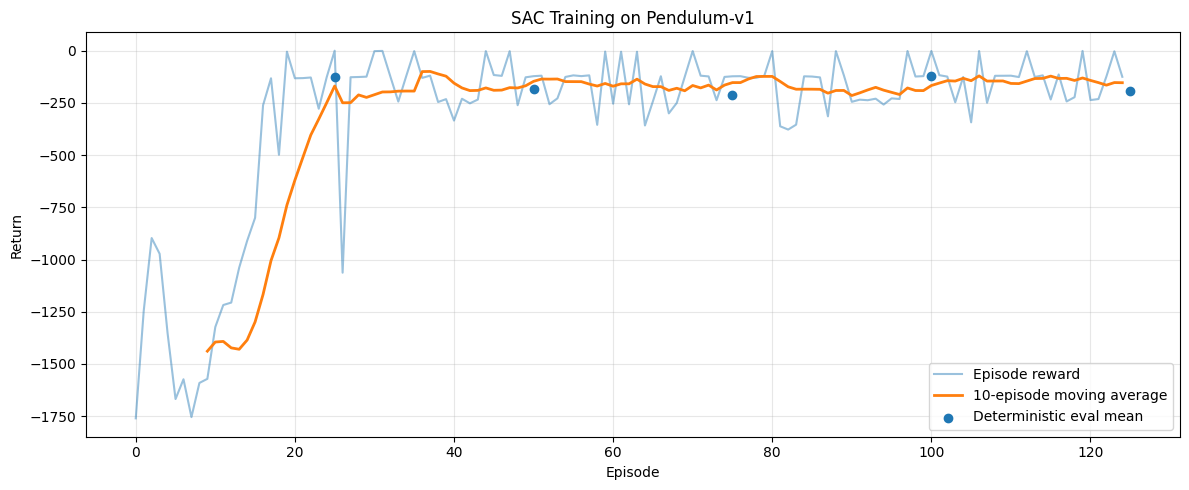

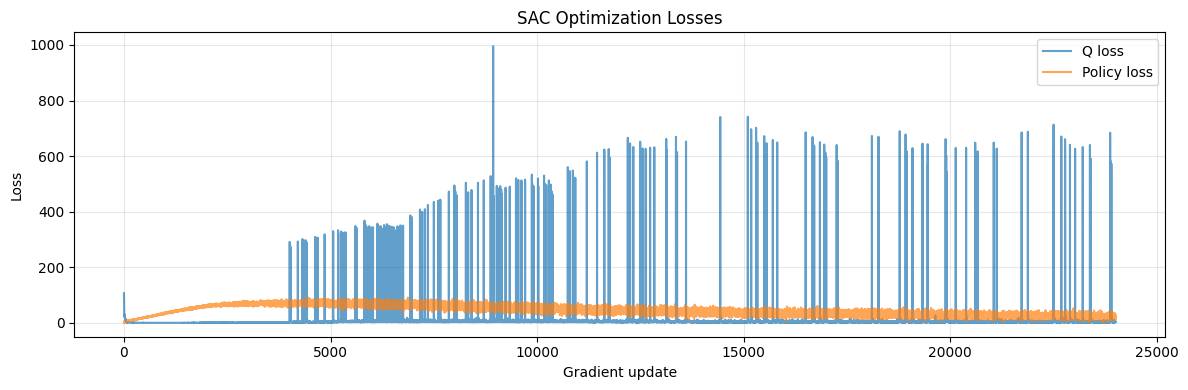

In [5]:
import gymnasium as gym
import matplotlib.pyplot as plt

seed = 0
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

env = gym.make("Pendulum-v1")
env.reset(seed=seed)
env.action_space.seed(seed)

agent = RunSAC(
    env=env,
    lr=1e-3,
    batch_size=100,
    gamma=0.99,
    polyak=0.995,
    alpha=0.2,
    hidden_sizes=(256, 256),
    replay_size=100_000,
    start_steps=1_000,
    update_after=1_000,
    update_every=50,
    max_ep_len=200,
)

episode_rewards, losses, eval_returns = agent.learn(
    total_steps=25_000,
    eval_every=5_000,
    num_test_episodes=5,
)
env.close()

window = min(10, len(episode_rewards))
moving_average = np.convolve(episode_rewards, np.ones(window) / window, mode="valid")

plt.figure(figsize=(12, 5))
plt.plot(episode_rewards, label="Episode reward", alpha=0.45)
plt.plot(
    range(window - 1, len(episode_rewards)),
    moving_average,
    label=f"{window}-episode moving average",
    linewidth=2,
)
if eval_returns:
    plt.scatter(
        [item["step"] / 200 for item in eval_returns],
        [item["mean_return"] for item in eval_returns],
        label="Deterministic eval mean",
        zorder=3,
    )
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("SAC Training on Pendulum-v1")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

if losses:
    q_losses = [item["loss_q1"] + item["loss_q2"] for item in losses]
    pi_losses = [item["loss_pi"] for item in losses]

    plt.figure(figsize=(12, 4))
    plt.plot(q_losses, label="Q loss", alpha=0.7)
    plt.plot(pi_losses, label="Policy loss", alpha=0.7)
    plt.xlabel("Gradient update")
    plt.ylabel("Loss")
    plt.title("SAC Optimization Losses")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

### 5. Multi-seed evaluation

Three seeds with identical hyperparameters, following the DQN and PPO notebooks. Each run is smoothed with a moving average, then the across-seed mean plus/minus one standard deviation is plotted.

This cell takes longer than the single-seed sanity check. Reduce `total_steps` while debugging the implementation, then raise it when collecting results for a report.

100%|██████████| 25000/25000 [01:12<00:00, 342.69it/s]


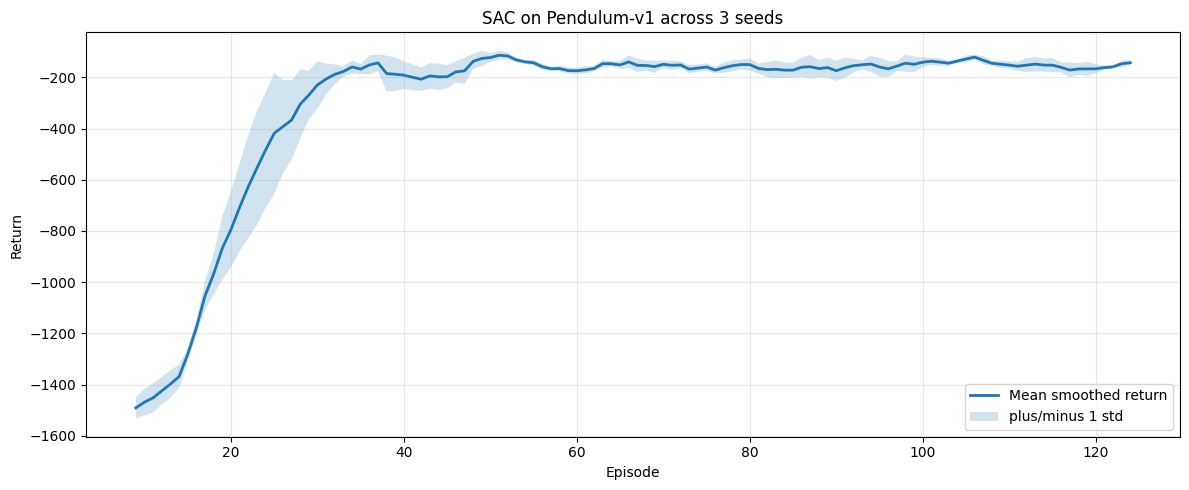

In [6]:
SEEDS = [0, 16, 25]
TOTAL_STEPS = 25_000
WINDOW = 10

reward_runs = []
eval_runs = []

for seed in SEEDS:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    env = gym.make("Pendulum-v1")
    env.reset(seed=seed)
    env.action_space.seed(seed)

    agent = RunSAC(
        env=env,
        lr=1e-3,
        batch_size=100,
        gamma=0.99,
        polyak=0.995,
        alpha=0.2,
        hidden_sizes=(256, 256),
        replay_size=100_000,
        start_steps=1_000,
        update_after=1_000,
        update_every=50,
        max_ep_len=200,
    )

    episode_rewards, _, eval_returns = agent.learn(
        total_steps=TOTAL_STEPS,
        eval_every=5_000,
        num_test_episodes=5,
    )
    env.close()

    reward_runs.append(np.array(episode_rewards, dtype=np.float32))
    eval_runs.append(eval_returns)

min_len = min(len(run) for run in reward_runs)
smoothed = []
for run in reward_runs:
    run = run[:min_len]
    smoothed.append(np.convolve(run, np.ones(WINDOW) / WINDOW, mode="valid"))

smoothed = np.vstack(smoothed)
mean_rewards = smoothed.mean(axis=0)
std_rewards = smoothed.std(axis=0)
x = np.arange(WINDOW - 1, WINDOW - 1 + len(mean_rewards))

plt.figure(figsize=(12, 5))
plt.plot(x, mean_rewards, label="Mean smoothed return", linewidth=2)
plt.fill_between(
    x,
    mean_rewards - std_rewards,
    mean_rewards + std_rewards,
    alpha=0.2,
    label="plus/minus 1 std",
)
plt.xlabel("Episode")
plt.ylabel("Return")
plt.title("SAC on Pendulum-v1 across 3 seeds")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()